# Activity 8.2 Topic Modeling

#### Objective(s):

This activity aims to introduce how to use LDA for topic modeling

#### Intended Learning Outcomes (ILOs):
* Demonstrate how to preprocess words in the dataset.
* Demonstrate how to create and build LDA model using specified number of topics

#### Resources:
* Jupyter Notebook
* fetch20 dataset

#### Procedures
Load the necessary libraries and datasets

Remove the headers, footers, and quotes from each member of the set

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data_path = '/content/drive/MyDrive/Colab Notebooks/Dataset'

In [ ]:
import warnings
warnings.filterwarnings("ignore",category=DeprecationWarning)
import numpy as np
import nltk
import os
from sklearn import datasets

categories = ['alt.atheism', 'comp.graphics', 'rec.sport.baseball']
ng_train = datasets.fetch_20newsgroups(subset='train',
                                       categories=categories,
                                       remove=('headers',
                                               'footers', 'quotes'))

In [ ]:
print(ng_train.data[3])
print("++\n", ng_train.data[1504])
print("++\n", ng_train.data[1000])

     Since when does atheism mean trashing other religions?There must be a God
     of inbreeding to which you are his only son.
++
 

Why not use the PD C library for reading/writing TIFF files? It took me a
good 20 minutes to start using them in your own app.

Martin

--
---------------------------------------------------------------------------
++
 
Indeed, if the color teal on a team's uniforms is any indication of the
future, the Marlins are in dire trouble! Refer to the San Jose Sharks for
proof... But I have hope for the Marlins. I was a sometime member of the
Rene Lachemann fan club at the Oakland Coliseum, and have a deep respect
for the guy. He's a gem. And, of course, Walt Weiss gives that franchise
class. But yeah... whoever designed those uniforms was guilty of a paucity
of style and imagination. Ugghhh!


* Pre-process all words in your document, including removing stop words.
* Remove words that show up in more than 60% of the documents/
* Vectorize your documents using NGrams

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(ngram_range=(1, 2),
                                   stop_words='english',
                                   token_pattern="\\b[a-z][a-z]+\\b",
                                   lowercase=True,
                                   max_df = 0.6)

X = count_vectorizer.fit_transform(ng_train.data)

* Create an LDA model with 3 topics. You can do this with GenSim or SkLearn.
* Print out the topics and the 20 words most associated with that topic.
* Try using more or less topics, is there a sweet spot that allows us to separate out the three input classes?
* Find a document that is clearly about baseball, does the model choose it as dominantly the topic?
* Use pyLDAvis (pip install pyldavis) to create an interactive visualization of the topics

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
n_topics = 4
n_iter = 10
lda = LatentDirichletAllocation(n_components=n_topics,
                                max_iter=n_iter,
                                random_state=42,
                               learning_method='online')
data = lda.fit_transform(X)
data[0]

array([0.00246896, 0.00251041, 0.99253159, 0.00248904])

In [ ]:
print(ng_train.data[0]) # 99% composed of topic 3!




I happen to be a big fan of Jayson Stark.  He is a baseball writer for the 
Philadelphia Inquirer.  Every tuesday he writes a "Week in Review" column.  
He writes about unusual situations that occured during the week.  Unusual
stats.  He has a section called "Kinerisms of the Week" which are stupid
lines by Mets brodcaster Ralph Kiner.  Every year he has the LGTGAH contest.
That stands for "Last guy to get a hit."  He also writes for Baseball 
America.  That column is sort of a highlights of "Week in Review."  If you 
can, check his column out sometime.  He might make you laugh.

Rob Koffler



In [ ]:
def display_topics(model, feature_names, no_top_words):
    for ix, topic in enumerate(model.components_):
        print("Topic ", ix)
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))

display_topics(lda,count_vectorizer.get_feature_names_out(),20)

Topic  0
jesus matthew said people den col prophecy int away war men messiah den den radius prophet row isaiah psalm row col sea
Topic  1
don god people does just think know like jpeg atheism say image time good believe way use atheists file religion
Topic  2
year game good team think don just games like players better runs hit won league time baseball season win pitching
Topic  3
graphics image edu data mail software ftp pub available send images package computer information use files thanks program processing code


* Open a new dataset from dap_split.txt
* Split this raw file into a set of documents. There is a clear marker between each article.
* Clean the text data and prepare for modeling (note that each document has some <XYZ> tags as well as extra spaces)

In [ ]:

with open(os.path.join(data_path, 'ap.txt'),'r') as f:
    raw_text = f.read()
docs = raw_text.split('---')
docs[1]

"\n </TEXT>\n</DOC>\n<DOC>\n<DOCNO> AP901021-0008 </DOCNO>\n<TEXT>\n Here are the winning numbers picked Saturday night for the California Lottery's twice-weekly ``Lotto 6-53'' game: 9, 38, 6, 29, 7, 20, and the bonus number, 27.\n </TEXT>\n</DOC>\n<DOC>\n<DOCNO> AP900518-0012 </DOCNO>\n<TEXT>\n A three-judge federal panel on Thursday upheld the authority of the U.S. Army Corps of Engineers to determine the level of discharges from a Missouri River reservoir in South Dakota and North Dakota. The 8th U.S. Circuit Court of Appeals panel overturned a lower court order that releases from the Oahe reservoir be reduced, as had been requested by the drought-stricken states. The appeals panel said it had serious reservations about whether courts have jurisdiction over such decisions by the corps. In a brief order, the panel said it would spell out its legal reasoning later in a formal opinion. The tug-of-war over water rights pitted the corps and the states of Iowa, Nebraska, Kansas and Missou

In [ ]:
import re
match = re.compile("<[^>]*>").search
for i,doc in enumerate(docs):
    final = []
    temp = doc.split('\n')
    for line in temp:
        if not match(line):
            final.append(line)
    docs[i] = ' '.join(final).strip().lower().replace("`","").replace("'","")
docs[1]

'here are the winning numbers picked saturday night for the california lotterys twice-weekly lotto 6-53 game: 9, 38, 6, 29, 7, 20, and the bonus number, 27.  a three-judge federal panel on thursday upheld the authority of the u.s. army corps of engineers to determine the level of discharges from a missouri river reservoir in south dakota and north dakota. the 8th u.s. circuit court of appeals panel overturned a lower court order that releases from the oahe reservoir be reduced, as had been requested by the drought-stricken states. the appeals panel said it had serious reservations about whether courts have jurisdiction over such decisions by the corps. in a brief order, the panel said it would spell out its legal reasoning later in a formal opinion. the tug-of-war over water rights pitted the corps and the states of iowa, nebraska, kansas and missouri against north dakota, south dakota and montana over whether water flow should be reduced from the reservoir, which stretches from pierre

In [ ]:
print(len(docs))

37


Do LDA modeling to find topics in this chain of articles. Try many different numbers of topics and processing techniques.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(ngram_range=(1, 3),
                                   stop_words='english',
                                   token_pattern="\\b[a-z][a-z]+\\b",
                                   lowercase=True,
                                   max_df = 0.6)

X = count_vectorizer.fit_transform(docs)

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
n_topics = 25
n_iter = 10
lda = LatentDirichletAllocation(n_components=n_topics,
                                max_iter=n_iter,
                                random_state=42,
                               learning_method='online')
data = lda.fit_transform(X)

In [ ]:
def display_topics(model, feature_names, no_top_words, topic_names=None):
    for ix, topic in enumerate(model.components_):
        if not topic_names or not topic_names[ix]:
            print("\nTopic ", ix)
        else:
            print("\nTopic: '",topic_names[ix],"'")
        print(", ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))
display_topics(lda,count_vectorizer.get_feature_names_out(),20) # We have to look at the topics before hand and then add the labels afterwards


Topic  0
percent, million, year, government, people, state, states, soviet, years, court, day, tuesday, american, billion, news, company, police, did, officials, national

Topic  1
year, stormie, percent, government, state, people, years, police, soviet, time, national, million, states, stormie jones, told, officials, billion, new york, wednesday, court

Topic  2
year, people, percent, state, government, million, soviet, years, police, states, house, officials, time, today, told, say, day, report, week, company

Topic  3
year, percent, government, states, million, years, time, national, soviet, police, billion, people, week, federal, day, officials, state, thursday, group, court

Topic  4
people, year, percent, soviet, years, million, day, government, time, state, federal, officials, court, police, south, states, billion, american, market, union

Topic  5
people, year, million, percent, government, time, police, states, thursday, state, today, soviet, officials, years, city, billion, 

In [ ]:
tn = ["Political Media",None,"Financials",None,"Nordstrom Scandal","Oil","Hurricanes","North Korea","NASA","US Politics","TV Networks","Forest Fires",
      None,"Agriculture/Drought","Middle East","US Political Campaigns","Pollution","Carribean","Health/Medical","Theatre/Arts","Global Warming",
      "Advertisements","Southern US Weather","South America",None]
display_topics(lda,count_vectorizer.get_feature_names_out(),20,topic_names=tn)


Topic: ' Political Media '
percent, million, year, government, people, state, states, soviet, years, court, day, tuesday, american, billion, news, company, police, did, officials, national

Topic  1
year, stormie, percent, government, state, people, years, police, soviet, time, national, million, states, stormie jones, told, officials, billion, new york, wednesday, court

Topic: ' Financials '
year, people, percent, state, government, million, soviet, years, police, states, house, officials, time, today, told, say, day, report, week, company

Topic  3
year, percent, government, states, million, years, time, national, soviet, police, billion, people, week, federal, day, officials, state, thursday, group, court

Topic: ' Nordstrom Scandal '
people, year, percent, soviet, years, million, day, government, time, state, federal, officials, court, police, south, states, billion, american, market, union

Topic: ' Oil '
people, year, million, percent, government, time, police, states, thursday

## Analysis
> From what I have gathered here, this procedure shows us how to load the data into Count Vectorizer to prepare or transform the data for topic modelling in LDA. So firstly, the data was extracted. Then, the data extracted is transformed or cleaned. The cleaned data is then added to Count Vectorizer to make the raw text into matrix of word counts. The matrix of word count is used by the LDA to determine which words are clustered together. The words clustered together are then were classified into topics.

# Supplementary Activity

* Use your own dataset
* Perform preprocessing of words in the dataset
* Create LDA model using a specified number of topics

**Additional instructions for Supplementary Evaluation**

Show at least 2 examples of datapoints for each topic
(Optional) Plot the clustering of topics using TruncatedSVD, KMeans, TSNE using a Scatter Plot'



## Extract

https://www.kaggle.com/datasets/datatattle/covid-19-nlp-text-classification


In [ ]:
import pandas as pd

data = pd.read_csv(os.path.join(data_path, "Corona_NLP.csv"), encoding='UTF-8',
                    encoding_errors='replace')
data.head(5)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3799,48751,London,16-03-2020,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive
2,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive
3,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive
4,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative


In [ ]:
data.shape

(41157, 6)

In [ ]:
data = data.sample(n=1000, random_state = 1234).reset_index(drop=True)

In [ ]:
data.shape

(1000, 6)

> Data is about Tweets about the Pandemic.

## Transform

In [ ]:
import re

def remove_noise(text):
    text = re.sub(r'http\S+', '', text)        # remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)   # remove numbers & special chars
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra whitespace
    return text

data.OriginalTweet = data.OriginalTweet.apply(remove_noise)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(ngram_range=(1, 2),
                                   stop_words='english',
                                   token_pattern="\\b[a-z][a-z]+\\b",
                                   lowercase=True,
                                   max_df = 0.6)

X = count_vectorizer.fit_transform(data.OriginalTweet)

## Load

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
n_topics = 5
n_iter = 10

lda = LatentDirichletAllocation(n_components=n_topics,
                                max_iter=n_iter,
                                random_state=42,
                               learning_method='online')
data_lda = lda.fit_transform(X)
data_lda[0]

array([0.02509703, 0.02516969, 0.02525142, 0.8993809 , 0.02510096])

In [ ]:
display_topics(lda,count_vectorizer.get_feature_names_out(),20)


Topic  0
coronavirus, covid, store, grocery, grocery store, consumer, amp, food, buying, prices, panic, people, like, panic buying, business, covid coronavirus, supermarket, workers, employees, just

Topic  1
coronavirus, covid, supermarket, people, store, prices, grocery, food, toilet, paper, grocery store, sanitizer, toilet paper, home, time, stores, hand, amp, toiletpaper, pandemic

Topic  2
covid, coronavirus, food, prices, demand, store, supermarket, pandemic, grocery, consumer, covid pandemic, stock, grocery store, amp, social, im, crisis, coronavirus covid, people, help

Topic  3
covid, online, shopping, coronavirus, supermarket, online shopping, prices, home, shop, amp, consumer, price, work, people, grocery, elderly, store, covid coronavirus, scams, update

Topic  4
coronavirus, prices, amp, covid, demand, increased, coronaviruspandemic, oil, pandemic, meet, people, oil prices, market, meet increased, markets, manchester, special, coronavirusoutbreak, city, borisjohnson


In [ ]:
topic_names = ['Panic Buying & Grocery Store Impact',
               'Hoarding of Essential Goods',
               'Food Supply & Demand Crisis',
               'Online Shopping & Consumer Scams',
               'Economic & Market Impact']

In [127]:
display_topics(lda,count_vectorizer.get_feature_names_out(), 20,
               topic_names=topic_names)


Topic: ' Panic Buying & Grocery Store Impact '
coronavirus, covid, store, grocery, grocery store, consumer, amp, food, buying, prices, panic, people, like, panic buying, business, covid coronavirus, supermarket, workers, employees, just

Topic: ' Hoarding of Essential Goods '
coronavirus, covid, supermarket, people, store, prices, grocery, food, toilet, paper, grocery store, sanitizer, toilet paper, home, time, stores, hand, amp, toiletpaper, pandemic

Topic: ' Food Supply & Demand Crisis '
covid, coronavirus, food, prices, demand, store, supermarket, pandemic, grocery, consumer, covid pandemic, stock, grocery store, amp, social, im, crisis, coronavirus covid, people, help

Topic: ' Online Shopping & Consumer Scams '
covid, online, shopping, coronavirus, supermarket, online shopping, prices, home, shop, amp, consumer, price, work, people, grocery, elderly, store, covid coronavirus, scams, update

Topic: ' Economic & Market Impact '
coronavirus, prices, amp, covid, demand, increased, c

In [128]:
doc_topic_matrix = lda.transform(count_vectorizer.transform(data.OriginalTweet))

topic = doc_topic_matrix.argmax(axis=1)

data['topic'] = topic

In [129]:
# create dict for mapping
tn = {}

for i in range(len(topic_names)):
    tn[i] = topic_names[i]

In [130]:
data['topic'] = data.topic.map(tn)

### OUTPUT: 5 Datapoints each Topics

In [131]:
data.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment,topic
0,17987,62939,"Brooklyn, NY",21-03-2020,Anyone else keep wondering how it would be dif...,Neutral,Online Shopping & Consumer Scams
1,19521,64473,Florida,22-03-2020,Ran out of toilet paper CoronavirusPandemic CO...,Neutral,Hoarding of Essential Goods
2,32992,77944,Yorkshire and The Humber,05-04-2020,This isnt just MampS food This is every bluddy...,Negative,Food Supply & Demand Crisis
3,5069,50021,Seattle Area,17-03-2020,Just went to the grocery store for essentials ...,Negative,Food Supply & Demand Crisis
4,13870,58822,"Santa Barbara, CA",20-03-2020,Inventory planning is the name of the game rig...,Negative,Panic Buying & Grocery Store Impact


In [132]:
# to show all the column outputs
pd.set_option('display.max_colwidth', None)

In [138]:
# Panic Buying & Grocery Store Impact
data.OriginalTweet[data.topic == topic_names[0]].head()

,OriginalTweet
4,Inventory planning is the name of the game right now in packaged staples as brands dealing with sudden surges in demand owing to try to predict how long current buying patterns might last
20,Im ashamed to be a part of this city right now Not seeing much evidence of coming together COVID coronavirus StopHoarding panicbuyinguk London
21,As part of the consumer coronavirus response we also saw early hoarding of important hygeinic and medical supplies like hand sanitizer sterilizing wipes and most importantly surgical masks We should note that these hoarding behaviors were global
22,All Hot Topic stores will be closed for a period of time due to health concerns During this time all store employees will be paid
36,BankofAmerica will allow borrowers to pause their mortgage payments BAC residential RealEstate lender loans coronavirus support consumer small business clients HomeEquity CreditCards


In [139]:
# Hoarding of Essential Goods
data.OriginalTweet[data.topic == topic_names[1]].head()

,OriginalTweet
1,Ran out of toilet paper CoronavirusPandemic COVID toiletpaper coronavirus
8,Cant believe Ive just gone to order my tesco online shopping and there isnt a single pack of fresh chicken Along with pasta toilet roll hand soap and more Cant believe how Coronavirus has shown such an grotesque side of society Greedy selfish bastards coronavirusuk
11,Fuel for Thought CrudeOil prices have corrected by almost since Dec as a result of the Covid crisis As one of the largest oil importers in the world India imports around of its oil demand
12,CoronaNews Hungarian oil and gas company MOL has switched over a production line to sanitizers made earlier windshield cleaner fluid Hungary MOL sanitizer coronavirus Read more Picture
13,COVID We have recently seen an increase in people shopping online In the short term this is having an impact on how we serve our customers You will notice that we are currently out of stock on some brands amp items in household staples categories


In [140]:
# Food Supply & Demand Crisis
data.OriginalTweet[data.topic == topic_names[2]].head()

,OriginalTweet
2,This isnt just MampS food This is every bluddy supermarket you go to lack of shoppers to buy food coronavirus Corvid lockdown
3,Just went to the grocery store for essentials carbohydrates and it was a little weird None of the usual milling just people getting their stuff and GTFO COVID grocerystores SocialDistancing
14,For those who arent in panic mode yet when would you suggest No food Tanks in the street Right now I dont even know anymore or who to trust coronavirus
16,Has anyone experienced getting headaches even if slight from shopping in a grocery store which was full of shoppers not SocialDistancing A theory suggests buildings arent properly ventilated to allow the contaminated COVID air from the breath of shoppers to dissipate
17,Day still havent needed to go to a supermarket Am I doing this wrong coronavirus


In [141]:
# Online Shopping & Consumer Scams
data.OriginalTweet[data.topic == topic_names[3]].head()

,OriginalTweet
0,Anyone else keep wondering how it would be different if HillaryClinton were president
5,covid Isolation how on earth will you ask us to stay at home no work no food no money to stock the housenaija hmmmmm if no body is crying out pls and pls o hear my cry o i need money so the isolation thing can work o make i come isolate die of hunger donjazzy iruntow
6,Direct Went togrocery storedropped offfor elderly before I headed back home I REMOVEDoutsidethen hit Grocery store controlledline by havin only a handful ofavail Nuntilturn to shop it helped with Soc
7,The impact of coronavirus on Singapore Private Home Prices Down In Q
9,This past week stories from all over America show farmers dumping milk plowing under crops because normal demand shifts Look we have Million hungry Americans without incomes TRUMPs Fed Govt IS FAILING AGAIN If Americans survive COVID we must face food shortages next


In [142]:
# Economic & Market Impact
data.OriginalTweet[data.topic == topic_names[4]].head()

,OriginalTweet
18,merry incognitonunya KeithCo cdnpoli uspoli coronavirus CoronavirusPandemic Vicki today my supermarket had toilet paper wrapped in totally clear plastic no printing whatsoever I figure the paper was made crushed sandpap
23,Shops markets shopping malls and restaurants remain closed in different cities of Pakistan as the country has imposed a ban on movement to stop the spread of The following pictures show the empty roads in Karachi Islamabad and Bannu Photos Online
39,NSTnation The streets were extra quiet with plenty of parking spaces available at shopping malls Gaya Street a major city centre thoroughfare was deserted as well MCO MovementControlOrder coronavirus covid sabah
63,Manchester City on Twitter Manchester City and Manchester United have donated a combined to help food banks in Greater Manchester meet increased demand from vulnerable people as a result of the coronavirus COVID pandemic via rMCFC
74,I live in Beijing China here s how the city and most of the country are managing everyday life in the midst of the Coronavirus pandemic They ve got supermarket clerks kitted up like the man from Breaking Bad


## Visualize
(Optional) Plot the clustering of topics using TruncatedSVD, KMeans, TSNE using a Scatter Plot

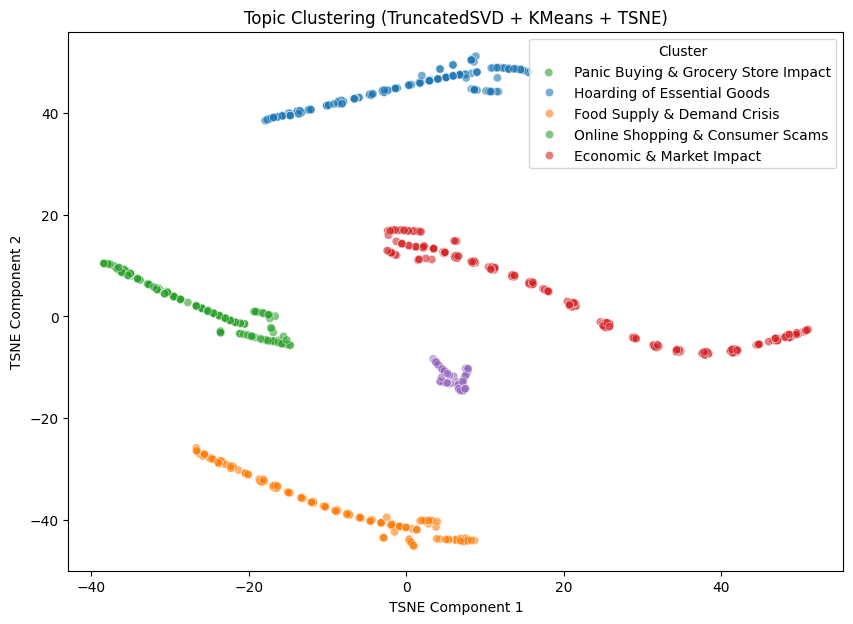

In [145]:
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

#Truncated SVD
svd = TruncatedSVD(n_components=5, random_state=42)
doc_svd = svd.fit_transform(doc_topic_matrix)

# Cluster with KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(doc_svd)

# Reduce to 2D with TSNE for visualization
tsne = TSNE(n_components=2, random_state=42)
doc_tsne = tsne.fit_transform(doc_svd)

# Plot
plt.figure(figsize=(10, 7))
scatter = sns.scatterplot(
    x=doc_tsne[:, 0],
    y=doc_tsne[:, 1],
    hue=clusters,
    palette='tab10',
    legend='full',
    alpha=0.6
)

plt.title("Topic Clustering (TruncatedSVD + KMeans + TSNE)")
plt.xlabel("TSNE Component 1")
plt.ylabel("TSNE Component 2")
plt.legend(title='Cluster', labels=list(tn.values()))
plt.show()

# Conclusion

> In this lab activity, I was able to learn how to do Topic Modeling using Count Vectorizer and LDA. In the procedure, I was introduced to use Count Vectorizer and LDA in creating a Topic Modelling. For the supplementary activity, I used a data about Tweets during the Corona Virus Pandemic. I sampled the data into 1,000 datapoints because I consume easily the alotted RAM in Google Colab. I transformed the data by removing special characters and the URLs. Then, I load the clean data into the Count Vectorizer. I load the data from Count Vectorzier in LDA to create a topic modelling. Using the 20 word outputs for each 5 topics, I categorized each topic. For the visualization, I used TruncatedSVD, KMeans, and TSNE. It returned a scatterplot with clusters for each group of topics. Overall, this lab activity helped understand how to create topics based on a collection of texts using LDA.